# SMF 04 · Star-forming and quiescent SMFs in radial bins vs. the field

Total, quiescent and star-forming SMFs of the stacked MACH sample in three radial bins (0–0.5, 0.5–1, 1–2 R200; from the `02a` runs) next to the field SMFs with their MCMC Schechter fits (Figure 15).

**Inputs**: `SMF_results/MACH_total_Rbin_*.npz`, `../../FIELD/FieldSMF_total.csv`, `FieldSMF_starforming.csv`, `FieldSMF_quiescent.csv`

**Output**: `FIGURE/IMAGES/Figure15.pdf`

In [15]:
# ============================================================================
# Setup
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

# The nine MACH clusters
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']

# Repository root, located relative to this notebook; DATA/ and FIGURE/ hang off it
MAINPATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
FIGUREPATH = f"{MAINPATH}/FIGURE/IMAGES"

%config InlineBackend.figure_format = 'retina'

In [16]:
# Load MACH master catalog
mach_path = f"{MAINPATH}/DATA/MACH_MASS/MACH_DR18_3R200_mastercat.csv"
mach_data = pd.read_csv(mach_path)

# Correct cmodel magnitudes for extinction
for band in ("g", "r"):
    mach_data[f"cmodelMag_{band}_0"] = (
        mach_data[f"cmodelMag_{band}"] - mach_data[f"extinction_{band}"]
    )

# Load HeCS VAC catalog
hecs_vac_path = f"{MAINPATH}/DATA/MACH_PHOT/AllHeCS_VAC_updated.csv"
hecs_vac_data = pd.read_csv(hecs_vac_path)

df = mach_data.copy()

# 1. One radial bin

In [17]:
# =============================================================
# Load saved results (use this in another notebook/session to plot)
# =============================================================

def load_mach_total_results(path='MACH_total_results.npz'):
    """Load .npz and return the same structure as `result` (for plotting)."""
    d = np.load(path, allow_pickle=True)
    fit_labels = list(d['fit_labels'])
    fit_results = {
        lbl: (d['fit_median'][i], d['fit_lower'][i], d['fit_upper'][i])
        for i, lbl in enumerate(fit_labels)
    }
    return {
        'mean_all': d['mean_all'],
        'mean_quenched': d['mean_quenched'],
        'mean_sf': d['mean_sf'],
        'original_counts': d['original_counts'],
        'bin_centers': d['bin_centers'],
        'complim': float(d['complim']),
        'fit_results': fit_results,
    }

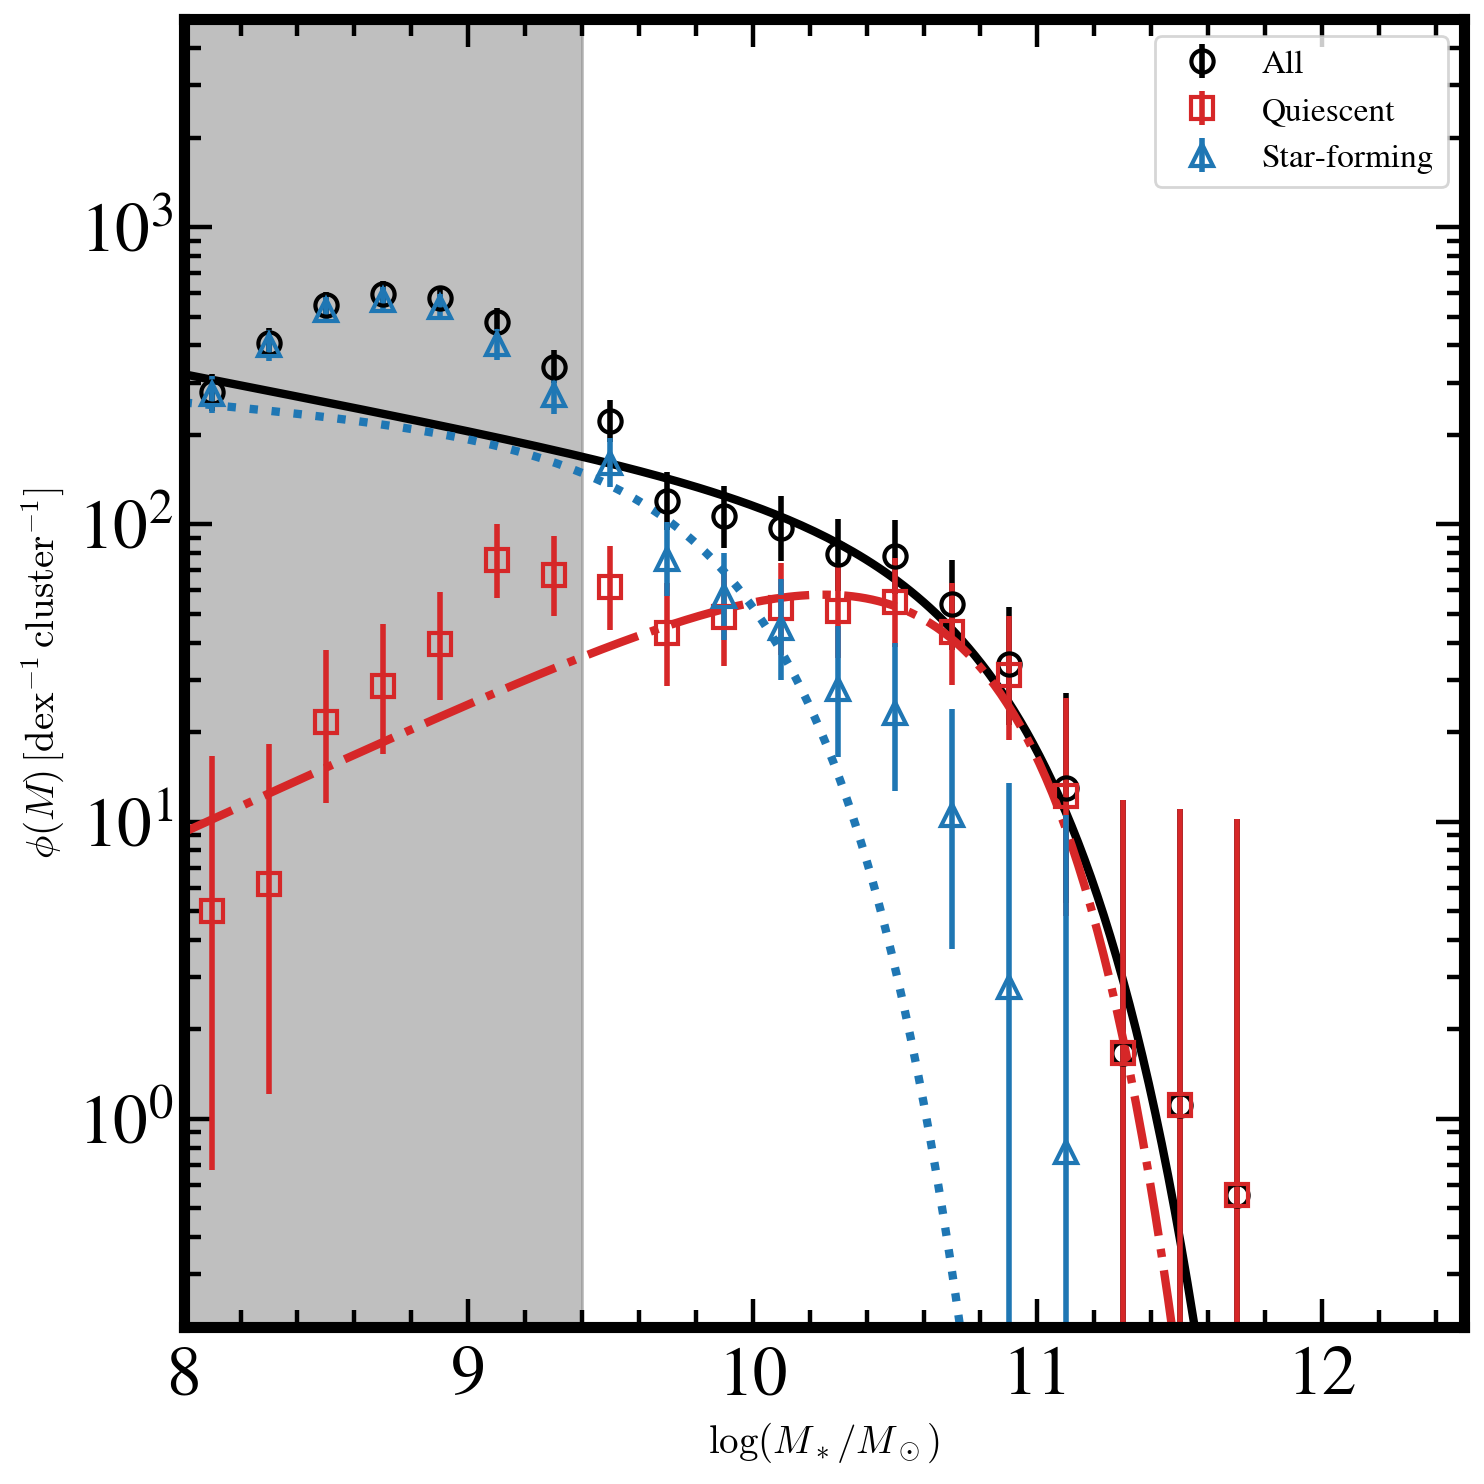

In [18]:
# Load one radial bin and unpack the arrays used below
result = load_mach_total_results('./SMF_results/MACH_total_Rbin_1p0to2p0R200.npz')
mean_all, mean_q, mean_sf = result['mean_all'], result['mean_quenched'], result['mean_sf']
original_counts, bin_centers = result['original_counts'], result['bin_centers']
SMF_complimit, fit_results = result['complim'], result['fit_results']
bin_width = 0.2

def schechter_1D_SMF(M, phi_0, M_star, alpha):
    """Schechter function per dex."""
    x = M - M_star
    return np.log(10) * phi_0 * 10**((1 + alpha) * x) * np.exp(-10**x)

# Single panel: All / Quiescent / Star-forming
fig, ax = plt.subplots(figsize=(8, 8))

# Shade the region below the completeness limit
ax.axvspan(bin_centers.min(), SMF_complimit, color='gray', alpha=0.5)

# Datasets and styles
datasets = {
    'All':          mean_all,
    'Quiescent':    mean_q,
    'Star-forming': mean_sf,
}
markers    = {'All': 'o', 'Quiescent': 's', 'Star-forming': '^'}
colors     = {'All': "#000000", 'Quiescent': "#d62728", 'Star-forming': '#1f77b4'}
linestyles = {'All': '-', 'Quiescent': '-.', 'Star-forming': ':'}

for label, hist in datasets.items():
    # number density (per dex)
    hist_norm = hist / bin_width

    # Gehrels (1986) asymmetric Poisson errors
    yerr_up  = (np.sqrt(hist + 0.75) + 1) / bin_width
    yerr_low = np.sqrt(np.clip(hist - 0.25, 0.25, None)) / bin_width
    mask     = hist > 0

    # Data points with error bars
    ax.errorbar(
        bin_centers[mask], hist_norm[mask],
        yerr=[yerr_low[mask], yerr_up[mask]],
        fmt=markers[label],
        color=colors[label],
        markerfacecolor='none',
        markeredgecolor=colors[label],
        markersize=8,
        markeredgewidth=1.5,
        ecolor=colors[label],
        capsize=0,
        label=label
    )

    # Schechter fit
    phi0, Mstar, alpha = fit_results[label][0]
    M_fit = np.linspace(8, 12.5, 200)
    ax.plot(
        M_fit,
        schechter_1D_SMF(M_fit, phi0, Mstar, alpha),
        color=colors[label],
        lw=3,
        linestyle=linestyles[label]
    )

# Axes
ax.set_yscale('log')
ax.set_xlim(8, 12.5)
ax.set_ylim(0.2, 5000)
ax.set_xlabel(r'$\log(M_*/M_\odot)$', fontsize=14)
ax.set_ylabel(r'$\phi(M)\,[\mathrm{dex}^{-1}\,\mathrm{cluster}^{-1}]$', fontsize=14)

ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 2. Field SMFs with MCMC fits

Burn-in [Total]:   0%|          | 0/500 [00:00<?, ?it/s]

Sampling [Quiescent]: 100%|██████████| 1500/1500 [00:02<00:00, 706.71it/s]


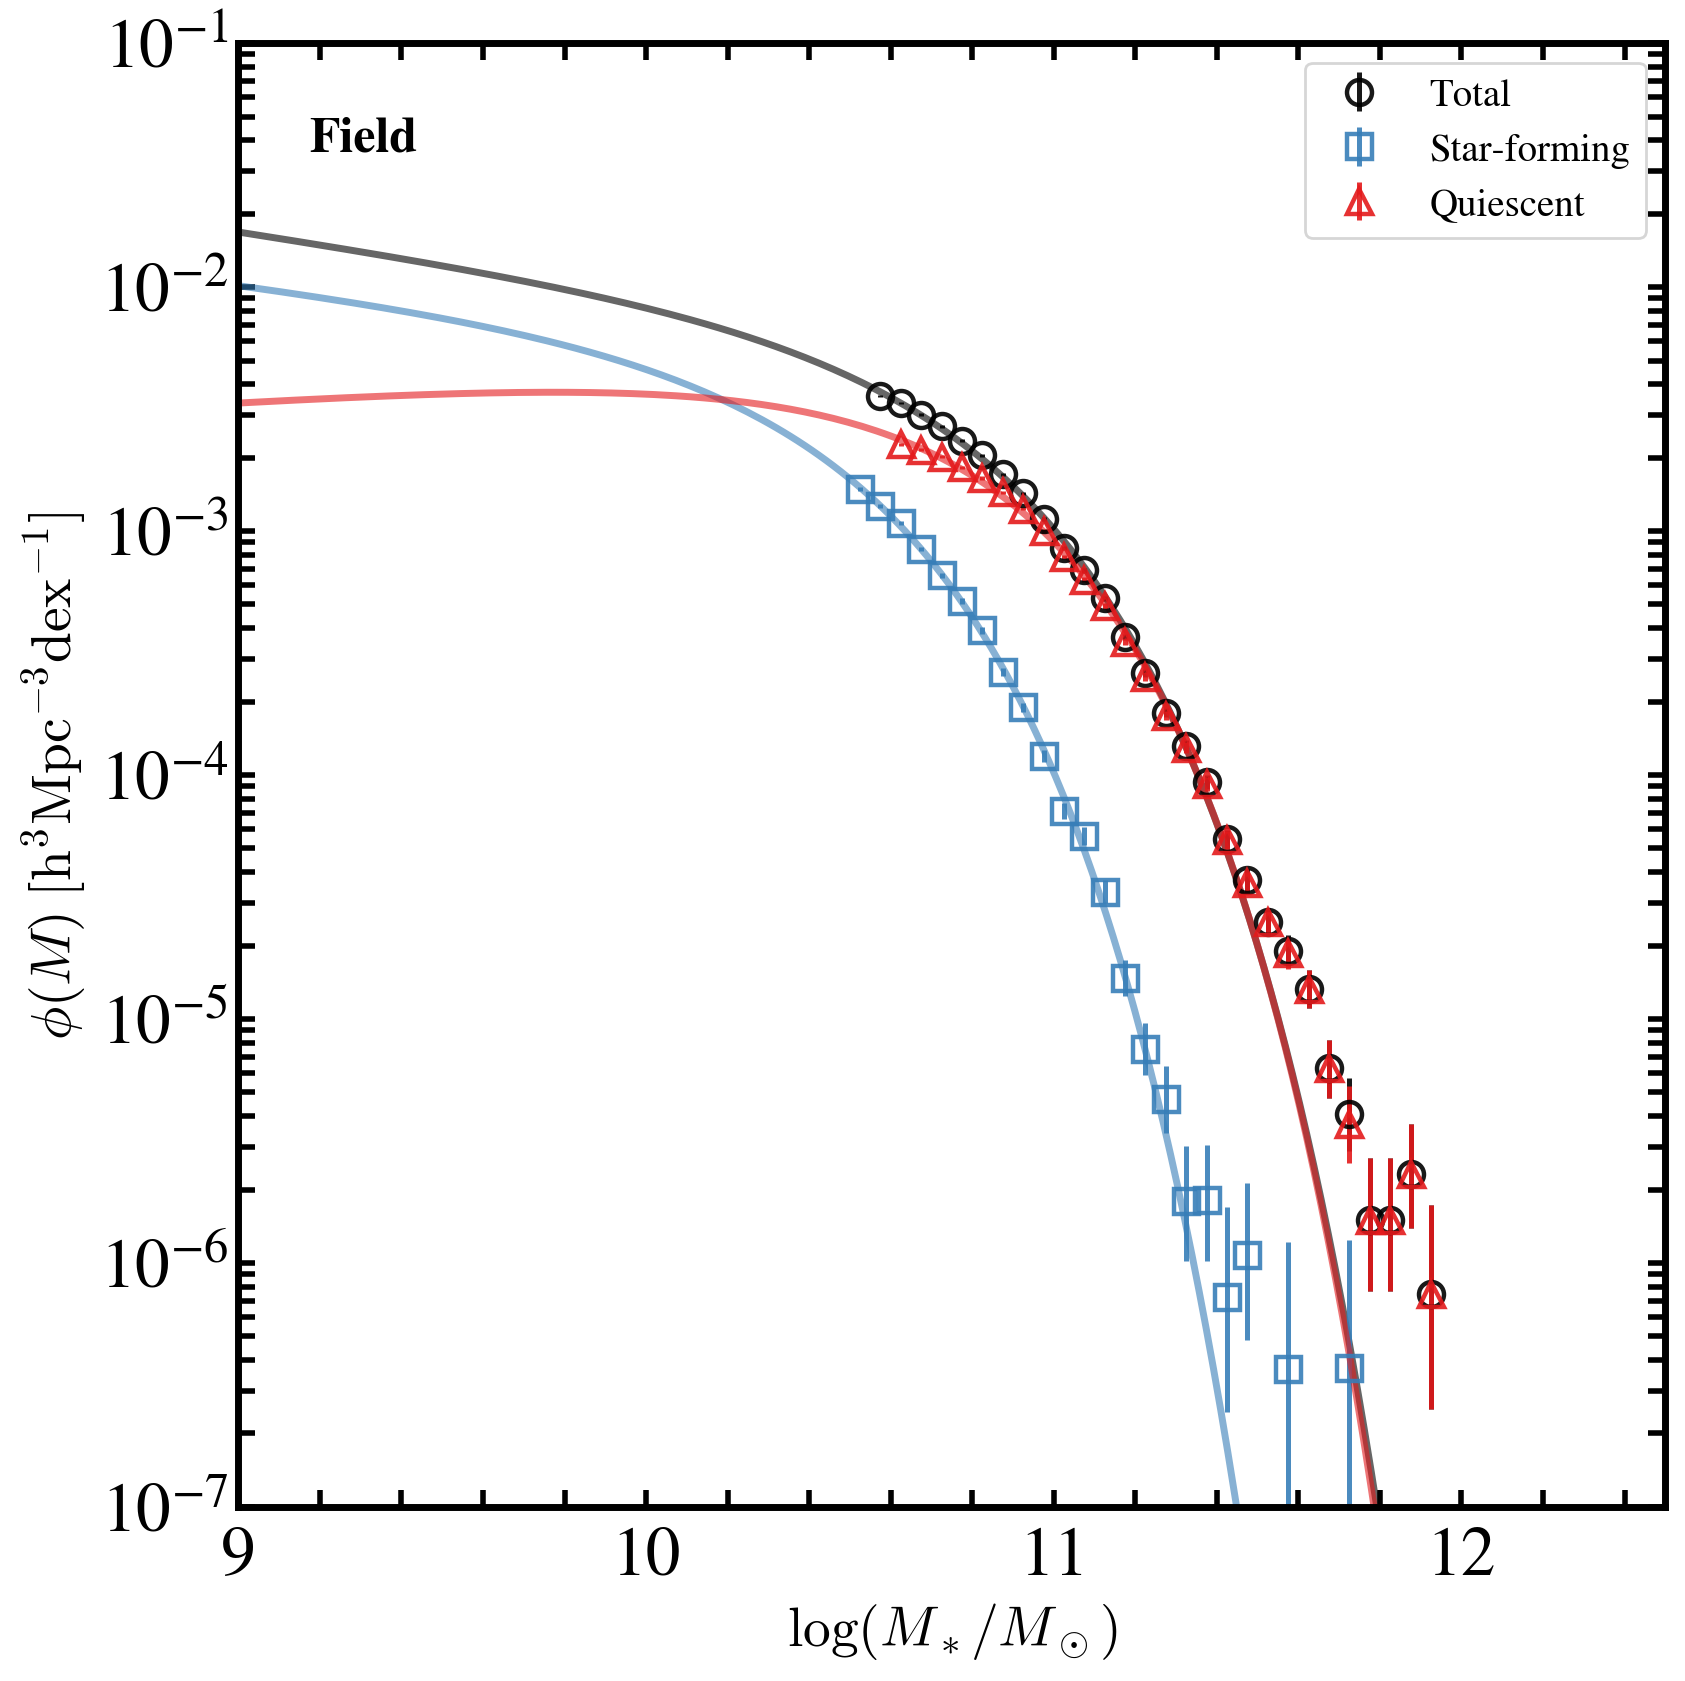

In [24]:
import emcee
from tqdm import tqdm

# --- Load data ---
field_smf_total = pd.read_csv(f'{MAINPATH}/CODE/FIELD/FieldSMF_total.csv')
field_smf_starforming = pd.read_csv(f'{MAINPATH}/CODE/FIELD/FieldSMF_starforming.csv')
field_smf_quiescent = pd.read_csv(f'{MAINPATH}/CODE/FIELD/FieldSMF_quiescent.csv')

field_smf_starforming = field_smf_starforming[field_smf_starforming['logM']>10.5]
# --- Schechter function ---
def schechter_1D_SMF(M, phi_0, M_star, alpha):
    return np.log(10) * phi_0 * (10 ** ((1 + alpha) * -(M_star - M))) * np.exp(-10 ** -(M_star - M))

# --- Log-likelihood ---
def log_likelihood(theta, x, y, yerr):
    phi_0, M_star, alpha = theta
    model = schechter_1D_SMF(x, phi_0, M_star, alpha)
    return -0.5 * np.sum(((y - model) / yerr) ** 2)

# --- Log-prior ---
def log_prior(theta):
    phi_0, M_star, alpha = theta
    if 0 < phi_0 < 1e4 and 8 < M_star < 13 and -2 < alpha < 1:
        return 0.0
    return -np.inf

# --- Log-posterior ---
def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    return lp + log_likelihood(theta, x, y, yerr) if np.isfinite(lp) else -np.inf

# --- Run MCMC with hyperparameters ---
def run_mcmc_with_progress(df, label, nwalkers=32, nburn=300, nsteps=1000):
    x = df['logM'].values
    y = df['phi_Mpc-3_dex-1'].values
    yerr = 0.5 * (df['phi_err_low'].values + df['phi_err_up'].values)

    ndim = 3
    initial = np.array([1e-3, 10.7, -1.0])
    pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, yerr))

    # Burn-in
    for _ in tqdm(range(nburn), desc=f"Burn-in [{label}]"):
        pos, _, _ = sampler.run_mcmc(pos, 1, progress=False)
    sampler.reset()

    # Sampling
    for _ in tqdm(range(nsteps), desc=f"Sampling [{label}]"):
        pos, _, _ = sampler.run_mcmc(pos, 1, progress=False)

    return sampler.get_chain(flat=True)

# --- Set MCMC hyperparameters here ---
nwalkers = 40
nburn = 500
nsteps = 1500

# --- Run MCMC ---
samples_total = run_mcmc_with_progress(field_smf_total, "Total", nwalkers, nburn, nsteps)
samples_sf = run_mcmc_with_progress(field_smf_starforming, "Star-forming", nwalkers, nburn, nsteps)
samples_q = run_mcmc_with_progress(field_smf_quiescent, "Quiescent", nwalkers, nburn, nsteps)

# --- Schechter Function ---
def schechter_1D_SMF(M, phi_0, M_star, alpha):
    return np.log(10) * phi_0 * (10 ** ((1 + alpha) * -(M_star - M))) * np.exp(-10 ** -(M_star - M))

# --- Plot Fit Function ---
def plot_fit(ax, df, sample_chain, color, label, marker):
    x = df['logM'].values
    y = df['phi_Mpc-3_dex-1'].values
    yerr = [df['phi_err_low'].values, df['phi_err_up'].values]

    # Median parameter values
    phi_0, M_star, alpha = np.median(sample_chain, axis=0)

    # Data with error bars
    ax.errorbar(x, y, yerr=yerr, fmt=marker, markerfacecolor='none',
                markeredgecolor=color, markeredgewidth=1.6, markersize=9,
                linewidth=2, ecolor=color, elinewidth=1.8, alpha=0.9, label=label)

    # Best-fit Schechter line
    x_model = np.linspace(9, 12.5, 200)
    y_model = schechter_1D_SMF(x_model, phi_0, M_star, alpha)
    ax.plot(x_model, y_model, color=color, linestyle='-', linewidth=2.5, alpha=0.6)

# --- Create single-panel figure ---
fig, ax = plt.subplots(figsize=(9, 9))

# Plot each population
plot_fit(ax, field_smf_total, samples_total, 'black', 'Total', 'o')
plot_fit(ax, field_smf_starforming, samples_sf, '#377eb8', 'Star-forming', 's')
plot_fit(ax, field_smf_quiescent, samples_q, '#e41a1c', 'Quiescent', '^')

# Axis styling
ax.set_yscale('log')
ax.set_xlabel(r'$\log(M_*/M_\odot)$', fontsize=20)
ax.set_ylabel(r'$\phi(M)\;[\mathrm{h}^{3}\mathrm{Mpc}^{-3}\mathrm{dex}^{-1}]$', fontsize=20)
ax.set_xlim(9, 12.5)
ax.set_ylim(1e-7, 1e-1)
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True,
               width=2, length=6)
ax.minorticks_on()
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

ax.legend(fontsize=14)
ax.text(0.05, 0.95, 'Field', transform=ax.transAxes,
        fontsize=18, weight='bold', va='top', ha='left', color='black')

plt.tight_layout()
plt.show()

# 3. Radial bins and field side by side (Figure 15)

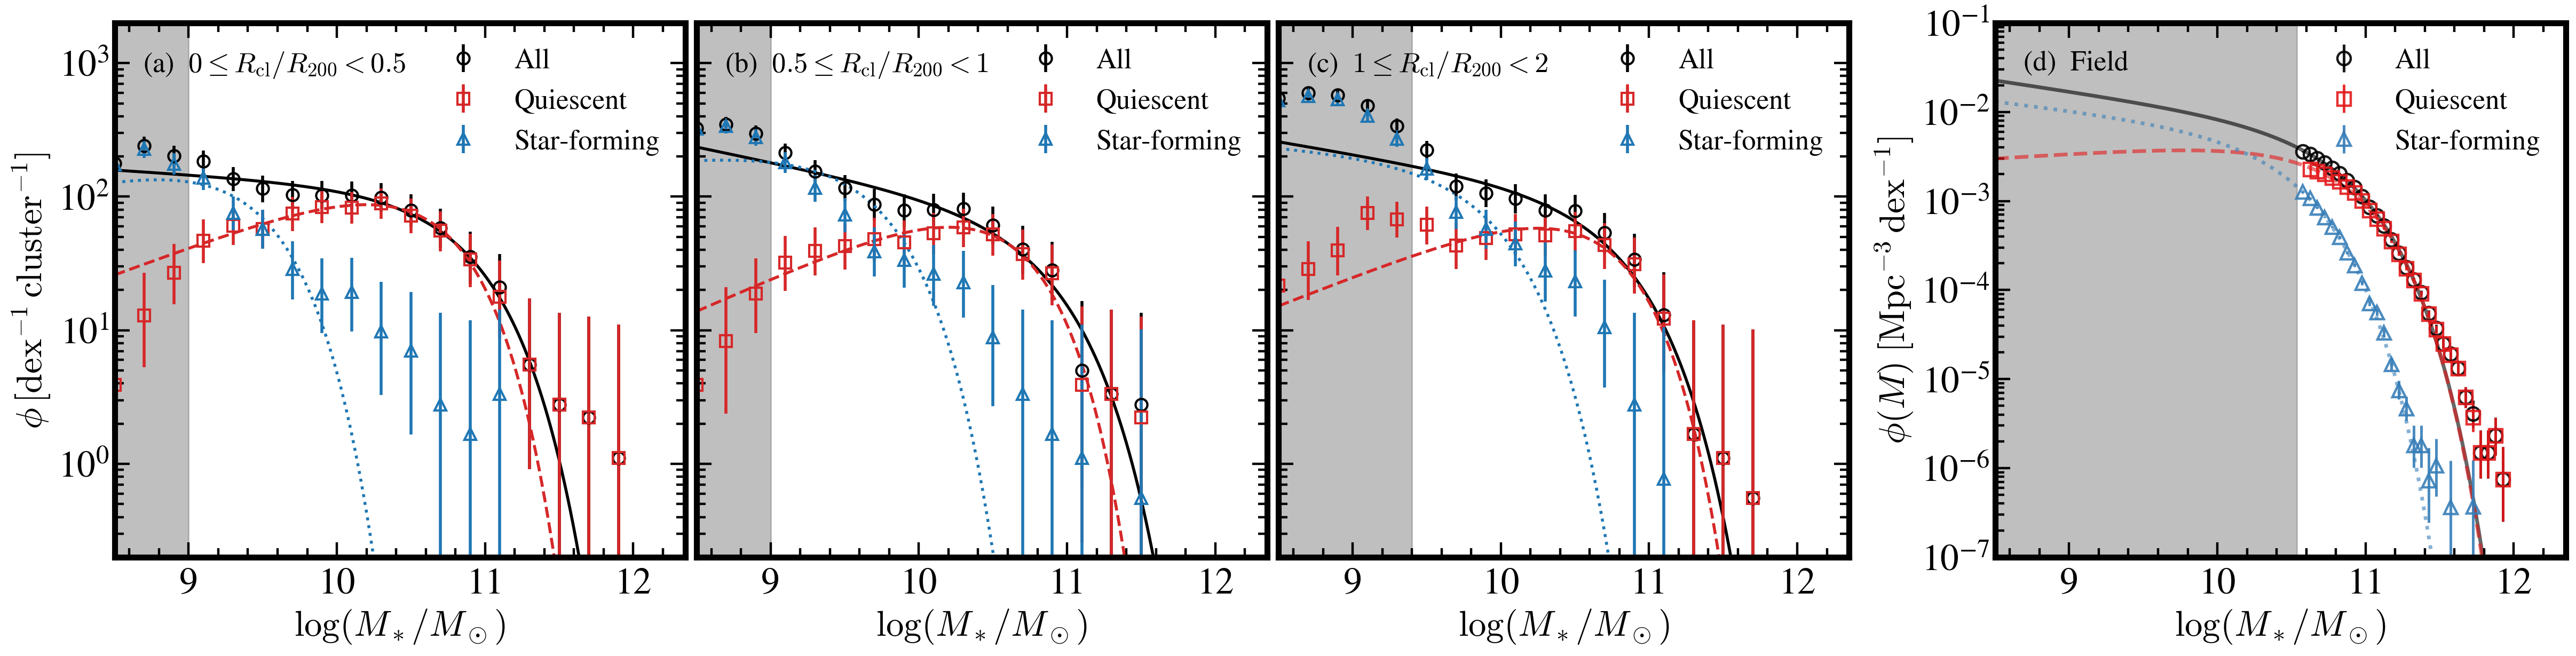

In [29]:
# =============================================================
# Uses the following from the cells above:
#   - load_mach_total_results()   (the .npz loader)
#   - samples_total, samples_sf, samples_q  (field MCMC chains)
#   - field_smf_total, field_smf_starforming, field_smf_quiescent (field DataFrames)
# =============================================================

# =============================================================
# Schechter function
# =============================================================
def schechter_1D_SMF(M, phi_0, M_star, alpha):
    x = M - M_star
    return np.log(10) * phi_0 * 10**((1 + alpha) * x) * np.exp(-10**x)

# =============================================================
# Field-panel helper: plot data + MCMC best-fit Schechter curve
#   - x_min_data:   do NOT plot data points below this mass
#   - x_model_min:  start the model line at this mass
# =============================================================
def plot_fit(ax, df, sample_chain, color, label, marker,
             linestyle='-', x_min_data=None, x_model_min=None, x_model_max=12.35,
             plot_line=True):
    x  = df['logM'].values
    y  = df['phi_Mpc-3_dex-1'].values
    yl = df['phi_err_low'].values
    yu = df['phi_err_up'].values

    # Mask out points below completeness (for field panel)
    if x_min_data is not None:
        mask = x >= x_min_data
        x, y, yl, yu = x[mask], y[mask], yl[mask], yu[mask]

    yerr = [yl, yu]

    # Median MCMC parameters
    phi_0, M_star, alpha = np.median(sample_chain, axis=0)

    # Data points with error bars
    if x.size > 0:
        ax.errorbar(
            x, y, yerr=yerr,
            fmt=marker, markerfacecolor='none',
            markeredgecolor=color, markeredgewidth=1.6, markersize=9,
            ecolor=color, elinewidth=1.8, capsize=0,
            alpha=0.9, label=label
        )

    # Best-fit Schechter curve (extend over full x-range of panel)
    if plot_line:
        if x_model_min is None:
            x_model_min = x.min() if x.size > 0 else 8.5
        M_fit  = np.linspace(x_model_min, x_model_max, 200)
        y_model = schechter_1D_SMF(M_fit, phi_0, M_star, alpha)
        ax.plot(M_fit, y_model, color=color, linestyle=linestyle, lw=2.5, alpha=0.6)

# =============================================================
# Load the three radial-bin cluster .npz files
# =============================================================
cluster_files = [
    ('./SMF_results/MACH_total_Rbin_0p0to0p5R200.npz',
     r"$0 \leq R_\mathrm{cl}/R_{200} < 0.5$"),
    ('./SMF_results/MACH_total_Rbin_0p5to1p0R200.npz',
     r"$0.5 \leq R_\mathrm{cl}/R_{200} < 1$"),
    ('./SMF_results/MACH_total_Rbin_1p0to2p0R200.npz',
     r"$1 \leq R_\mathrm{cl}/R_{200} < 2$"),
]
cluster_results = [
    (load_mach_total_results(path), annotation)
    for path, annotation in cluster_files
]

# =============================================================
# Style definitions (shared across cluster panels)
# =============================================================
datasets_style = {
    'All':          {'marker': 'o', 'color': '#000000', 'linestyle': '-' },
    'Quiescent':    {'marker': 's', 'color': '#d62728', 'linestyle': '--'},
    'Star-forming': {'marker': '^', 'color': '#1f77b4', 'linestyle': ':' },
}

# =============================================================
# Build 1 × 4 figure  (3 cluster panels + 1 field panel)
# =============================================================
panel_letters = ['(a)', '(b)', '(c)', '(d)']

fig, axes = plt.subplots(
    1, 4,
    figsize=(28, 6.5),
    gridspec_kw={'wspace': 0.02}
)

# ------------------------------------------------------------------
# Panels 0–2: cluster radial bins
# ------------------------------------------------------------------
for i, (res, annotation) in enumerate(cluster_results):
    ax = axes[i]
    bc      = res['bin_centers']
    bw      = float(bc[1] - bc[0])
    complim = res['complim']

    hists = {
        'All':          res['mean_all'],
        'Quiescent':    res['mean_quenched'],
        'Star-forming': res['mean_sf'],
    }

    for lbl, style in datasets_style.items():
        hist = hists[lbl]
        phi  = hist / bw
        mask = hist > 0

        # Gehrels asymmetric Poisson errors
        yerr_up = (np.sqrt(hist + 0.75) + 1) / bw
        yerr_lo = np.sqrt(np.clip(hist - 0.25, 0.25, None)) / bw

        # Data points
        ax.errorbar(
            bc[mask], phi[mask],
            yerr=[yerr_lo[mask], yerr_up[mask]],
            fmt=style['marker'],
            color=style['color'],
            markerfacecolor='none',
            markeredgewidth=1.5,
            markersize=8,
            ecolor=style['color'],
            capsize=0,
            label=lbl
        )

        # Best-fit Schechter curves for all three components
        #   - black solid   : All
        #   - red dashed    : Quiescent
        #   - blue dotted   : Star-forming
        if lbl in res['fit_results']:
            phi0, Mstar, alpha = res['fit_results'][lbl][0]
            M_fit = np.linspace(8.5, 12.35, 200)
            ax.plot(
                M_fit,
                schechter_1D_SMF(M_fit, phi0, Mstar, alpha),
                color=style['color'], lw=2, linestyle=style['linestyle']
            )

    # Shade incomplete region
    ax.axvspan(bc.min(), complim, color='gray', alpha=0.5)

    # Panel label + radial annotation
    ax.text(0.05, 0.95, f"{panel_letters[i]}  {annotation}",
            transform=ax.transAxes, va='top', ha='left', fontsize=19)

    # Axes style
    ax.set_yscale('log')
    ax.set_xlim(8.5, 12.35)
    ax.set_ylim(0.2, 2000)
    ax.set_xlabel(r'$\log(M_*/M_\odot)$', fontsize=24)
    if i == 0:
        ax.set_ylabel(r'$\phi\,[\mathrm{dex}^{-1}\,\mathrm{cluster}^{-1}]$', fontsize=24)
    else:
        ax.set_yticklabels([])

    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)
    for spine in ax.spines.values():
        spine.set_linewidth(4)
    ax.legend(fontsize=19, frameon=False)

# ------------------------------------------------------------------
# Panel 3: field SMF
#   - Only plot solid black fit line for total SMF
#   - No red or blue fit lines
#   - Still plot all data points
# ------------------------------------------------------------------
ax = axes[3]
pos_d = axes[3].get_position()
axes[3].set_position([pos_d.x0 + 0.045, pos_d.y0, pos_d.width, pos_d.height])

field_complim = 10.538  # same as gray shaded limit

# --- Plot total (black), plus red dashed (quiescent) and blue dotted (star-forming) Schechter fits ---
field_sets = [
    # (df, samples, color, label, marker, linestyle, plot_line)
    (field_smf_total,       samples_total, '#000000', 'All',          'o', '-',  True),   # black solid
    (field_smf_quiescent,   samples_q,     '#e41a1c', 'Quiescent',    's', '--', True),   # red dashed
    (field_smf_starforming, samples_sf,    '#377eb8', 'Star-forming', '^', ':',  True),   # blue dotted
]

for df_field, samples, color, label, marker, ls, plot_line in field_sets:
    plot_fit(
        ax, df_field, samples,
        color=color, label=label, marker=marker,
        linestyle=ls,
        x_min_data=field_complim,   # suppress data points below completeness
        x_model_min=8.5,            # model line from left edge of panel
        x_model_max=12.35,
        plot_line=plot_line
    )

# Shade field completeness region
ax.axvspan(8.5, field_complim, color='gray', alpha=0.5)

ax.text(0.05, 0.95, "(d)  Field",
        transform=ax.transAxes, va='top', ha='left', fontsize=19)

ax.set_yscale('log')
ax.set_xlim(8.5, 12.35)
ax.set_ylim(1e-7, 1e-1)
ax.set_xlabel(r'$\log(M_*/M_\odot)$', fontsize=24)
ax.set_ylabel(r'$\phi(M)\;[\mathrm{Mpc}^{-3}\,\mathrm{dex}^{-1}]$', fontsize=24)

# Put y-axis ticks/label on the LEFT (not right)
ax.yaxis.set_label_position('left')
ax.yaxis.tick_left()

ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=False)
for spine in ax.spines.values():
    spine.set_linewidth(4)
ax.legend(fontsize=19, frameon=False, loc='upper right')

# =============================================================
# Save & show
# =============================================================
plt.savefig(f"{MAINPATH}/FIGURE/IMAGES/Figure15.pdf",
            format='pdf', dpi=150, bbox_inches='tight')
plt.show()